## Part 2: Computer Vision Problem Formulation and CNN Prototype

## Task 1: Problem Identification

### Selected Problem Type: Image Classification

The dataset represents an image classification problem.

In image classification, each image has one label. For example, if the dataset contains images of different objects, the CNN model learns patterns from the images and predicts the correct object class.

This problem is not object detection because we do not need to draw boxes around objects.

This is because each image belongs to one category or class, and the goal of the CNN model is to predict the correct class label for the image.

This is not semantic segmentation because there are no pixel-level masks.

Therefore, image classification is the correct computer vision problem type for this dataset.

## Task 2: Dataset Exploration

Import Libraries

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

Define Dataset Path

In [2]:
dataset_path = "images"

Display Classes and Number of Classes

In [3]:
classes = os.listdir(dataset_path)

print("Classes in Dataset:")
print(classes)

print("\nTotal Number of Classes:", len(classes))

Classes in Dataset:
['.DS_Store', 'dent', 'normal', 'scratch', 'stain']

Total Number of Classes: 5


Number of Images Per Class

In [4]:
import os

classes = []

for item in os.listdir(dataset_path):

    item_path = os.path.join(dataset_path, item)

    if os.path.isdir(item_path):
        classes.append(item)

print("Classes in Dataset:")
print(classes)

print("\nTotal Number of Classes:", len(classes))

Classes in Dataset:
['dent', 'normal', 'scratch', 'stain']

Total Number of Classes: 4


In [ ]:
for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    total_images = len(os.listdir(class_path))

    print(class_name, ":", total_images, "images")

Display Sample Images From Each Class

In [ ]:
plt.figure(figsize=(12,5))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(1,4,i+1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

<Figure size 1200x500 with 0 Axes>

Check Image Dimensions

In [ ]:
for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    print(class_name, "image size:", image.size)

### Dataset Observations

- The dataset contains 4 classes:
  - normal
  - scratch
  - dent
  - stain

- Each folder contains images related to a specific manufacturing defect category.

- Sample images from each class were visualized.

- Image dimensions were checked before preprocessing.

- The dataset is suitable for image classification using CNN.

- If some classes contain more images than others, dataset imbalance may occur.

Task 3: Image Preprocessing

In [ ]:
!unzip images.zip


Archive:  images.zip
   creating: images/
  inflating: images/.DS_Store        
   creating: images/dent/
 extracting: images/dent/dent_001.png  
 extracting: images/dent/dent_002.png  
 extracting: images/dent/dent_003.png  
 extracting: images/dent/dent_004.png  
 extracting: images/dent/dent_005.png  
 extracting: images/dent/dent_006.png  
 extracting: images/dent/dent_007.png  
 extracting: images/dent/dent_008.png  
 extracting: images/dent/dent_009.png  
 extracting: images/dent/dent_010.png  
 extracting: images/dent/dent_011.png  
 extracting: images/dent/dent_012.png  
 extracting: images/dent/dent_013.png  
 extracting: images/dent/dent_014.png  
 extracting: images/dent/dent_015.png  
 extracting: images/dent/dent_016.png  
 extracting: images/dent/dent_017.png  
 extracting: images/dent/dent_018.png  
 extracting: images/dent/dent_019.png  
 extracting: images/dent/dent_020.png  
 extracting: images/dent/dent_021.png  
 extracting: images/dent/dent_022.png  
 extracting: i

Import libraries

In [ ]:
import os

print(os.listdir("images"))

['stain', 'normal', '.DS_Store', 'scratch', 'dent']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Set image size

In [ ]:
image_height = 128
image_width = 128
batch_size = 32

Create preprocessing

In [ ]:
data_generator = ImageDataGenerator(
    rescale=1/255,
    validation_split=0.2
)

Create training data

In [ ]:
train_data = data_generator.flow_from_directory(
    "images",
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

Create testing data

In [ ]:
test_data = data_generator.flow_from_directory(
    "images",
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

Show class names

In [ ]:
print(train_data.class_indices)

### Preprocessing Summary

In this step, all images were prepared for CNN model training.

The images were resized to 128 x 128 pixels so that every image has the same size.

Pixel values were normalized by dividing by 255, so the values changed from 0-255 to 0-1.

The dataset was split into training and testing data. 80% of the images were used for training and 20% were used for testing.

This preprocessing helps the CNN model learn better from the image dataset.

## Task 4: CNN Model Creation

Create Simple CNN Model

In [ ]:
import tensorflow as tf

In [ ]:
model = tf.keras.models.Sequential([

    tf.keras.Input(shape=(128,128,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(4, activation='softmax')

])

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Show model summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     8,128,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,129,732 (31.01 MB)

 Trainable params: 8,129,732 (31.01 MB)

 Non-trainable params: 0 (0.00 B)

### CNN Model Explanation

A simple CNN model was created for image classification.

The model contains:

- Convolution layer
- ReLU activation function
- Max pooling layer
- Flatten layer
- Dense layer
- Output layer

The convolution layer extracts image features.

The max pooling layer reduces image size and keeps important features.

The flatten layer converts the image into one-dimensional data.

The dense layer helps classify the images.

The output layer contains 4 neurons because the dataset has 4 classes:
- dent
- normal
- scratch
- stain

## Task 5: Model Training and Evaluation

Train Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (128,128)

batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "images",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

test_data = train_datagen.flow_from_directory(
    "images",
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


Check Accuracy

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 665ms/step - accuracy: 0.2448 - loss: 6.1019 - val_accuracy: 0.2500 - val_loss: 1.5772
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 517ms/step - accuracy: 0.3021 - loss: 1.4279 - val_accuracy: 0.3333 - val_loss: 1.3516
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 646ms/step - accuracy: 0.3698 - loss: 1.3209 - val_accuracy: 0.2604 - val_loss: 1.3393
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 518ms/step - accuracy: 0.3594 - loss: 1.2849 - val_accuracy: 0.2917 - val_loss: 1.3134
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 643ms/step - accuracy: 0.3542 - loss: 1.2332 - val_accuracy: 0.3021 - val_loss: 1.2977


In [ ]:
loss, accuracy = model.evaluate(test_data)

print("Accuracy:", accuracy)
print("Loss:", loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.2500 - loss: 1.4316
Accuracy: 0.25
Loss: 1.4316266775131226


Show Accuracy Graph

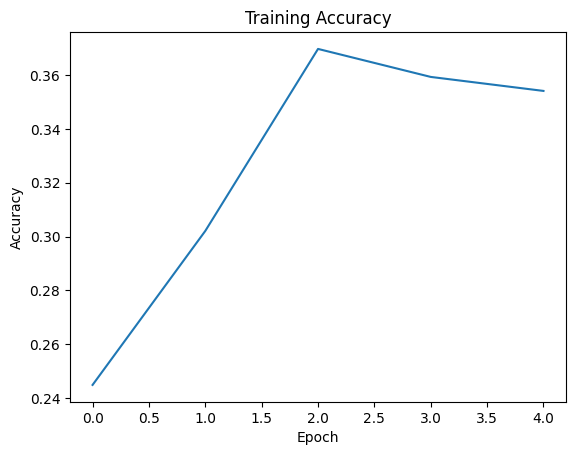

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

Show Loss Graph

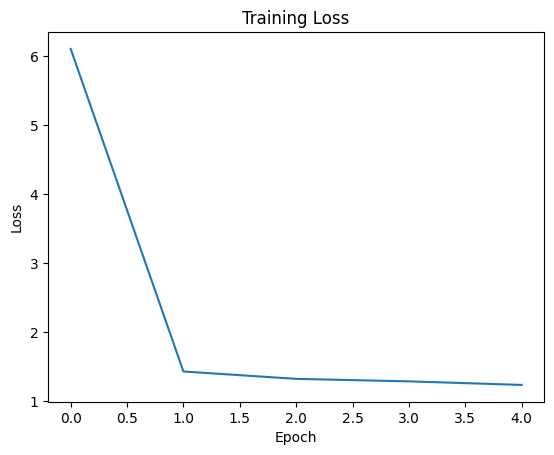

In [ ]:
plt.plot(history.history['loss'])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

Create Confusion Matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step


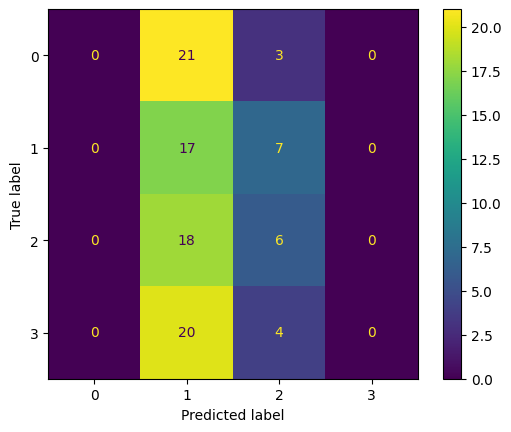

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

predictions = model.predict(test_data)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = test_data.classes

cm = confusion_matrix(true_labels, predicted_labels)

display = ConfusionMatrixDisplay(confusion_matrix=cm)

display.plot()

plt.show()

Show Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


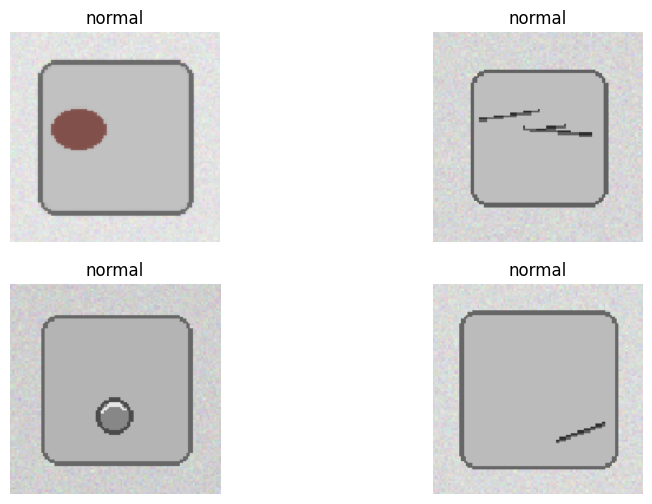

In [ ]:
images, labels = next(test_data)

predictions = model.predict(images)

class_names = ['dent', 'normal', 'scratch', 'stain']

plt.figure(figsize=(10,6))

for i in range(4):

    plt.subplot(2,2,i+1)

    plt.imshow(images[i])

    predicted_class = class_names[np.argmax(predictions[i])]

    plt.title(predicted_class)

    plt.axis("off")

plt.show()

### Model Training and Evaluation Summary

The CNN model was trained using the training dataset.

The model accuracy and loss were checked after training.

Graphs were created to show training accuracy and training loss.

A confusion matrix was created to compare predicted and actual classes.

Sample predictions were displayed on test images.

## Task 6: CNN Concept Explanation


### What is Convolution?

Convolution is a method used in CNN models to find important features in images. It helps the model detect things like edges, lines, shapes, and patterns from the image automatically.

---

### Why is Pooling Used?

Pooling is used to reduce the size of the image data. It helps make the model faster and removes extra information from the image while keeping the important features.

---

### Why is ReLU Commonly Used in CNNs?

ReLU is an activation function used in CNN models. It helps the model learn better and faster. ReLU changes negative values into zero and keeps positive values as they are.

---

### Why are CNNs Better Than Regular Feed-Forward Networks for Images?

CNNs are better for image data because they can automatically learn image features like shapes and patterns. CNNs also reduce calculations using convolution and pooling layers, which makes them more efficient for image processing.

## Task 7: Business Use Case Mapping

This type of computer vision model can be used in manufacturing industries.

The model can help identify defects like dents, scratches, and stains on products using images.

Instead of checking products manually, companies can use cameras and CNN models to detect damaged products automatically.

This can help save time, reduce human mistakes, and improve product quality.

In [6]:
!mkdir results

A subdirectory or file results already exists.


In [7]:
!mkdir sample_predictions

A subdirectory or file sample_predictions already exists.


In [10]:
!notepad requirements.txt